# Formula 1 Winners Analysis

A simple data analysis project exploring Formula 1 race winners form 1950 to mid 2025
The goal of this project is to find out who are the top 10 drivers with most wins in F1 history.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## Loading the data

loading the dataset from a CSV file 1,142 F1 races.

In [3]:
df = pd.read_csv("../data/winners_f1_1950_2025_v2.csv")
df.head()

,date,continent,grand_prix,circuit,winner_name,team,time,laps,year
0,1950-05-13,Europe,Great Britain,Silverstone Circuit,Nino Farina,Alfa Romeo,02:13:23,70.0,1950
1,1950-05-21,Europe,Monaco,Circuit de Monaco,Juan Manuel Fangio,Alfa Romeo,03:13:18,100.0,1950
2,1950-05-30,North America,United States,Indianapolis Motor Speedway,Johnnie Parsons,Kurtis Kraft Offenhauser,02:46:55,138.0,1950
3,1950-06-04,Europe,Switzerland,Circuit Bremgarten,Nino Farina,Alfa Romeo,02:02:53,42.0,1950
4,1950-06-18,Europe,Belgium,Circuit de Spa Francorchamps,Juan Manuel Fangio,Alfa Romeo,02:47:26,35.0,1950


## Saving to database

Storing the data in a local SQLite database.
The `if_exists="replace"` parameter make sure the table is always 
recreated when the notebook runs.

In [4]:
conn = sqlite3.connect("f1_winners.db")
df.to_sql("vencedores", conn, if_exists="replace", index=False)
conn.close()
print ("Data saved.")

Data saved.


## Top 10 most winning drivers

"Querying" the database to find the 10 drivers with the most race wins in F1 history.

In [5]:
conn = sqlite3.connect("../f1_winners.db")

query = """
SELECT winner_name, COUNT(winner_name) as tVitorias
FROM vencedores
GROUP BY winner_name
ORDER BY tVitorias DESC
LIMIT 10
"""

df_top10 = pd.read_sql(query, conn)
conn.close()
df_top10

,winner_name,tVitorias
0,Lewis Hamilton,105
1,Michael Schumacher,91
2,Max Verstappen,65
3,Sebastian Vettel,53
4,Alain Prost,51
5,Ayrton Senna,41
6,Fernando Alonso,32
7,Nigel Mansell,31
8,Jackie Stewart,27
9,Niki Lauda,25


## Visualization

Bar chart showing the top 10 most winning drivers of all time.

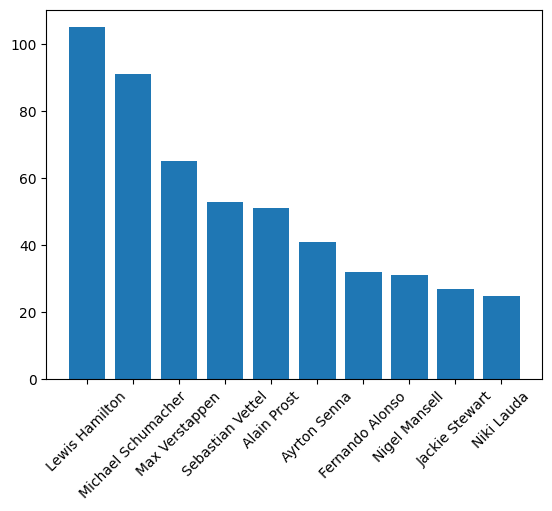

In [6]:
plt.bar(df_top10["winner_name"], df_top10["tVitorias"])
plt.xticks(rotation=45)
plt.show()

## Conclusion

Printing the most winning driver in F1 history based on the query results.

In [7]:
nome = df_top10['winner_name'].iloc[0]
vitorias = df_top10['tVitorias'].iloc[0]
print(f"The most winning driver in F1 history is {nome} with {vitorias} wins.")

The most winning driver in F1 history is Lewis Hamilton with 105 wins.


This project analyzed 1,142 Formula 1 races from 1950 to mid-2025.
Using Python and SQL it was possible to identify the top 10 most winning drivers in F1 history.